In [1]:
%matplotlib inline
# ================================================================
# STOCK MARKET PREDICTION — FULL ML LIFECYCLE  (FIXED v3)
# 60 NSE Stocks | 3 Categories | 6 Models | Real-Time Data
# ================================================================


In [2]:
# ================================================================
# CELL 1 — IMPORTS
# ================================================================
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
import ta
from datetime import datetime, timedelta
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score,
                             precision_score, recall_score, f1_score)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.base import BaseEstimator, ClassifierMixin

warnings.filterwarnings('ignore')
print('All libraries imported successfully')


c:\Users\rames\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


All libraries imported successfully


In [3]:
# ================================================================
# NEW-04 FIX: PreFittedVotingClassifier
# ================================================================
class PreFittedVotingClassifier(BaseEstimator, ClassifierMixin):
    """Soft-voting ensemble over ALREADY-FITTED estimators (no refit)."""

    def __init__(self, estimators):
        self.estimators = estimators

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        return self

    def predict_proba(self, X):
        probas = np.array([est.predict_proba(X) for _, est in self.estimators])
        return probas.mean(axis=0)

    def predict(self, X):
        avg_proba = self.predict_proba(X)
        return self.classes_[np.argmax(avg_proba, axis=1)]


In [4]:
# ================================================================
# STAGE 1 — PROBLEM DEFINITION
# ================================================================
print('\n' + '='*65)
print('STAGE 1 — PROBLEM DEFINITION')
print('='*65)
print('''
BUSINESS GOAL:
  Predict whether a given NSE stock will generate a positive
  return of more than 1% over the next 5 trading days.

ML PROBLEM TYPE:
  Binary Classification
    -> BUY  (1) : Expected 5-day return > 1%
    -> SELL (0) : Expected 5-day return <= 1%

SCOPE:
  60 NSE stocks across 3 market cap categories
  6 ML models trained per category = 18 total models
  Real-time data: last 7 years up to today
  Evaluation: Accuracy, Precision, Recall, F1, ROC-AUC

SUCCESS METRIC:
  Minimum acceptable accuracy : 55%
  Target accuracy             : 60%+
  Secondary metric            : ROC-AUC > 0.55
''')



STAGE 1 — PROBLEM DEFINITION

BUSINESS GOAL:
  Predict whether a given NSE stock will generate a positive
  return of more than 1% over the next 5 trading days.

ML PROBLEM TYPE:
  Binary Classification
    -> BUY  (1) : Expected 5-day return > 1%
    -> SELL (0) : Expected 5-day return <= 1%

SCOPE:
  60 NSE stocks across 3 market cap categories
  6 ML models trained per category = 18 total models
  Real-time data: last 7 years up to today
  Evaluation: Accuracy, Precision, Recall, F1, ROC-AUC

SUCCESS METRIC:
  Minimum acceptable accuracy : 55%
  Target accuracy             : 60%+
  Secondary metric            : ROC-AUC > 0.55



In [5]:
# ================================================================
# CELL 2 — STOCK UNIVERSE & GLOBAL CONSTANTS
# ================================================================
STOCKS = {
    # Large Cap — 20 stocks
    'RELIANCE.NS'   : 'Large Cap',
    'HDFCBANK.NS'   : 'Large Cap',
    'INFY.NS'       : 'Large Cap',
    'TCS.NS'        : 'Large Cap',
    'ICICIBANK.NS'  : 'Large Cap',
    'KOTAKBANK.NS'  : 'Large Cap',
    'LT.NS'         : 'Large Cap',
    'AXISBANK.NS'   : 'Large Cap',
    'HINDUNILVR.NS' : 'Large Cap',
    'ITC.NS'        : 'Large Cap',
    'SBIN.NS'       : 'Large Cap',
    'BAJFINANCE.NS' : 'Large Cap',
    'WIPRO.NS'      : 'Large Cap',
    'HCLTECH.NS'    : 'Large Cap',
    'MARUTI.NS'     : 'Large Cap',
    'SUNPHARMA.NS'  : 'Large Cap',
    'TITAN.NS'      : 'Large Cap',
    'ASIANPAINT.NS' : 'Large Cap',
    'BHARTIARTL.NS' : 'Large Cap',
    'ULTRACEMCO.NS' : 'Large Cap',

    # Mid Cap — 20 stocks
    'MUTHOOTFIN.NS' : 'Mid Cap',
    'VOLTAS.NS'     : 'Mid Cap',
    'PERSISTENT.NS' : 'Mid Cap',
    'COFORGE.NS'    : 'Mid Cap',
    'INDHOTEL.NS'   : 'Mid Cap',
    'TATACHEM.NS'   : 'Mid Cap',
    'CROMPTON.NS'   : 'Mid Cap',
    'MAXHEALTH.NS'  : 'Mid Cap',
    'PIIND.NS'      : 'Mid Cap',
    'GODREJPROP.NS' : 'Mid Cap',
    'LUPIN.NS'      : 'Mid Cap',
    'TATAELXSI.NS'  : 'Mid Cap',
    'BALKRISIND.NS' : 'Mid Cap',
    'OBEROIRLTY.NS' : 'Mid Cap',
    'JUBLFOOD.NS'   : 'Mid Cap',
    'HONAUT.NS'     : 'Mid Cap',
    'IPCALAB.NS'    : 'Mid Cap',
    'ALKEM.NS'      : 'Mid Cap',
    'SUNDARMFIN.NS' : 'Mid Cap',
    'CARBORUNIV.NS' : 'Mid Cap',

    # Small Cap — 20 stocks
    'NAZARA.NS'      : 'Small Cap',
    'KPITTECH.NS'    : 'Small Cap',
    'HAPPSTMNDS.NS'  : 'Small Cap',
    'LATENTVIEW.NS'  : 'Small Cap',
    'SAPPHIRE.NS'    : 'Small Cap',
    'MEDPLUS.NS'     : 'Small Cap',
    'SYRMA.NS'       : 'Small Cap',
    'FUSION.NS'      : 'Small Cap',
    'KAYNES.NS'      : 'Small Cap',
    'SENCO.NS'       : 'Small Cap',
    'BIKAJI.NS'      : 'Small Cap',
    'CRAFTSMAN.NS'   : 'Small Cap',
    'RAILTEL.NS'     : 'Small Cap',
    'FINEORG.NS'     : 'Small Cap',
    'DODLA.NS'       : 'Small Cap',
    'LXCHEM.NS'      : 'Small Cap',
    'RATEGAIN.NS'    : 'Small Cap',
    'CAMPUS.NS'      : 'Small Cap',
    'HARSHA.NS'      : 'Small Cap',
    'SBCL.NS'        : 'Small Cap',
}

CATEGORIES = ['Large Cap', 'Mid Cap', 'Small Cap']

FEATURES = [
    'SMA_Ratio_10',
    'SMA_Ratio_50',
    'RSI',
    'MACD_Pct',
    'MACD_Sig_Pct',
    'EMA_Ratio_20',
    'ATR_Pct',
    'Momentum',
    'Volume_Ratio',
    'BB_Width',
]

MAX_SVM_ROWS = 500

print(f'Total stocks  : {len(STOCKS)}')
print(f'Large Cap     : {sum(1 for v in STOCKS.values() if v == "Large Cap")}')
print(f'Mid Cap       : {sum(1 for v in STOCKS.values() if v == "Mid Cap")}')
print(f'Small Cap     : {sum(1 for v in STOCKS.values() if v == "Small Cap")}')
print(f'Features used : {FEATURES}')


Total stocks  : 60
Large Cap     : 20
Mid Cap       : 20
Small Cap     : 20
Features used : ['SMA_Ratio_10', 'SMA_Ratio_50', 'RSI', 'MACD_Pct', 'MACD_Sig_Pct', 'EMA_Ratio_20', 'ATR_Pct', 'Momentum', 'Volume_Ratio', 'BB_Width']


In [6]:
# ================================================================
# STAGE 2 — DATA COLLECTION  (Real-Time)
# ================================================================
print('\n' + '='*65)
print('STAGE 2 — DATA COLLECTION (Real-Time via yfinance)')
print('='*65)

END_DATE   = datetime.today().strftime('%Y-%m-%d')
START_DATE = (datetime.today() - timedelta(days=2557)).strftime('%Y-%m-%d')

print(f'Start Date : {START_DATE}')
print(f'End Date   : {END_DATE}  (auto-updated every run)')
print(f'NOTE: yfinance returns last market close, not live tick price.\n')

all_dfs       = []
failed_stocks = []

for symbol, category in STOCKS.items():
    try:
        df = yf.download(symbol, start=START_DATE, end=END_DATE, progress=False)

        if df.empty:
            print(f'Skipping {symbol} — no data returned')
            failed_stocks.append(symbol)
            continue

        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)

        required = ['Open', 'High', 'Low', 'Close', 'Volume']
        if not all(col in df.columns for col in required):
            print(f'Skipping {symbol} — missing columns')
            failed_stocks.append(symbol)
            continue

        df['Symbol']       = symbol
        df['Category']     = category
        df['Daily_Return'] = df['Close'].pct_change()
        df.dropna(subset=['Daily_Return'], inplace=True)

        if len(df) < 100:
            print(f'Skipping {symbol} — not enough rows ({len(df)})')
            failed_stocks.append(symbol)
            continue

        all_dfs.append(df)
        print(f'OK {symbol:<22} | {category:<10} | {len(df)} rows')

    except Exception as e:
        print(f'Error {symbol}: {e}')
        failed_stocks.append(symbol)
        continue

print(f'\nSuccessfully collected : {len(all_dfs)} stocks')
print(f'Failed / Skipped       : {len(failed_stocks)} stocks')
if failed_stocks:
    print(f'Failed list: {failed_stocks}')



STAGE 2 — DATA COLLECTION (Real-Time via yfinance)
Start Date : 2019-03-28
End Date   : 2026-03-28  (auto-updated every run)
NOTE: yfinance returns last market close, not live tick price.

OK RELIANCE.NS            | Large Cap  | 1729 rows
OK HDFCBANK.NS            | Large Cap  | 1729 rows
OK INFY.NS                | Large Cap  | 1729 rows
OK TCS.NS                 | Large Cap  | 1729 rows
OK ICICIBANK.NS           | Large Cap  | 1729 rows
OK KOTAKBANK.NS           | Large Cap  | 1729 rows
OK LT.NS                  | Large Cap  | 1729 rows
OK AXISBANK.NS            | Large Cap  | 1729 rows
OK HINDUNILVR.NS          | Large Cap  | 1729 rows
OK ITC.NS                 | Large Cap  | 1729 rows
OK SBIN.NS                | Large Cap  | 1729 rows
OK BAJFINANCE.NS          | Large Cap  | 1729 rows
OK WIPRO.NS               | Large Cap  | 1729 rows
OK HCLTECH.NS             | Large Cap  | 1729 rows
OK MARUTI.NS              | Large Cap  | 1729 rows
OK SUNPHARMA.NS           | Large Cap  | 1729

In [7]:
# ================================================================
# STAGE 3 — DATA PREPARATION & CLEANING
# ================================================================
print('\n' + '='*65)
print('STAGE 3 — DATA PREPARATION & CLEANING')
print('='*65)

cleaned_dfs = []

for raw_df in all_dfs:
    df       = raw_df.copy()
    symbol   = df['Symbol'].iloc[0]
    category = df['Category'].iloc[0]

    close = df['Close'].squeeze()
    high  = df['High'].squeeze()
    low   = df['Low'].squeeze()
    vol   = df['Volume'].squeeze()

    sma_10  = ta.trend.sma_indicator(close=close, window=10)
    sma_50  = ta.trend.sma_indicator(close=close, window=50)
    ema_20  = ta.trend.ema_indicator(close=close, window=20)
    atr     = ta.volatility.average_true_range(high=high, low=low, close=close)
    vol_ma  = vol.rolling(window=20).mean()

    macd_obj  = ta.trend.MACD(close=close)
    macd_raw  = macd_obj.macd()
    macd_sig  = macd_obj.macd_signal()

    bb_obj    = ta.volatility.BollingerBands(close=close, window=20)

    df['SMA_Ratio_10']  = close / sma_10
    df['SMA_Ratio_50']  = close / sma_50
    df['EMA_Ratio_20']  = close / ema_20
    df['ATR_Pct']       = atr / close * 100
    df['Volume_Ratio']  = vol / vol_ma
    df['MACD_Pct']      = macd_raw / close * 100
    df['MACD_Sig_Pct']  = macd_sig / close * 100
    df['RSI']           = ta.momentum.rsi(close=close, window=14)
    df['Momentum']      = close.pct_change(5)
    df['BB_Width']      = bb_obj.bollinger_wband()

    df['Future_Return'] = (close.shift(-5) - close) / close
    df['Target']        = (df['Future_Return'] > 0.01).astype(int)

    before = len(df)
    df.dropna(inplace=True)
    after  = len(df)

    if after < 60:
        print(f'Skipping {symbol} after cleaning — only {after} rows')
        continue

    cleaned_dfs.append(df)
    print(f'OK {symbol:<22} | Rows before: {before:<5} | After cleaning: {after}')

print(f'\nCleaning complete. {len(cleaned_dfs)} stocks ready for EDA & modelling.')

master_df = pd.concat(cleaned_dfs)
master_df.index.name = 'Date'
master_df.reset_index(inplace=True)
master_df.drop_duplicates(subset=['Date', 'Symbol'], inplace=True)
master_df.sort_values(['Symbol', 'Date'], inplace=True)
master_df.reset_index(drop=True, inplace=True)

print(f'\nMaster DataFrame Shape : {master_df.shape}')
print(f'Total Stocks Included  : {master_df["Symbol"].nunique()}')
print(f'Date Range             : {master_df["Date"].min()} to {master_df["Date"].max()}')
print(f'Categories             : {master_df["Category"].value_counts().to_dict()}')

print('\n--- NULL CHECK (Master) ---')
null_counts = master_df.isnull().sum()
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else 'No nulls found')

print('\n--- OUTLIER REPORT (IQR, informational only) ---')
for feat in FEATURES:
    q1  = master_df[feat].quantile(0.25)
    q3  = master_df[feat].quantile(0.75)
    iqr = q3 - q1
    n_out = ((master_df[feat] < q1 - 1.5*iqr) |
             (master_df[feat] > q3 + 1.5*iqr)).sum()
    print(f'  {feat:<18} : {n_out} outliers ({n_out/len(master_df)*100:.1f}%)')
print('  Note: Outliers retained — tree models are robust to them.')



STAGE 3 — DATA PREPARATION & CLEANING
OK RELIANCE.NS            | Rows before: 1729  | After cleaning: 1675
OK HDFCBANK.NS            | Rows before: 1729  | After cleaning: 1675
OK INFY.NS                | Rows before: 1729  | After cleaning: 1675
OK TCS.NS                 | Rows before: 1729  | After cleaning: 1675
OK ICICIBANK.NS           | Rows before: 1729  | After cleaning: 1675
OK KOTAKBANK.NS           | Rows before: 1729  | After cleaning: 1675
OK LT.NS                  | Rows before: 1729  | After cleaning: 1675
OK AXISBANK.NS            | Rows before: 1729  | After cleaning: 1675
OK HINDUNILVR.NS          | Rows before: 1729  | After cleaning: 1675
OK ITC.NS                 | Rows before: 1729  | After cleaning: 1675
OK SBIN.NS                | Rows before: 1729  | After cleaning: 1675
OK BAJFINANCE.NS          | Rows before: 1729  | After cleaning: 1675
OK WIPRO.NS               | Rows before: 1729  | After cleaning: 1675
OK HCLTECH.NS             | Rows before: 1729  | Af


STAGE 4 — EXPLORATORY DATA ANALYSIS (EDA)
Sample Stock for EDA : RELIANCE.NS

--- DESCRIBE (sample stock) ---
Price  SMA_Ratio_10  SMA_Ratio_50        RSI   MACD_Pct  MACD_Sig_Pct  \
count     1675.0000     1675.0000  1675.0000  1675.0000     1675.0000   
mean         1.0025        1.0140    52.0633     0.2542        0.2565   
std          0.0292        0.0706    12.4252     2.0273        1.8842   
min          0.8398        0.6460    16.9907   -15.0096      -12.1053   
25%          0.9863        0.9683    43.0761    -0.9024       -0.8372   
50%          1.0019        1.0035    51.6894     0.0903        0.0584   
75%          1.0188        1.0567    61.6629     1.5578        1.4375   
max          1.1433        1.2755    82.6480     6.0030        5.4415   

Price  EMA_Ratio_20    ATR_Pct   Momentum  Volume_Ratio   BB_Width     Target  
count     1675.0000  1675.0000  1675.0000     1675.0000  1675.0000  1675.0000  
mean         1.0048     2.2091     0.0033        1.0097    10.7849     

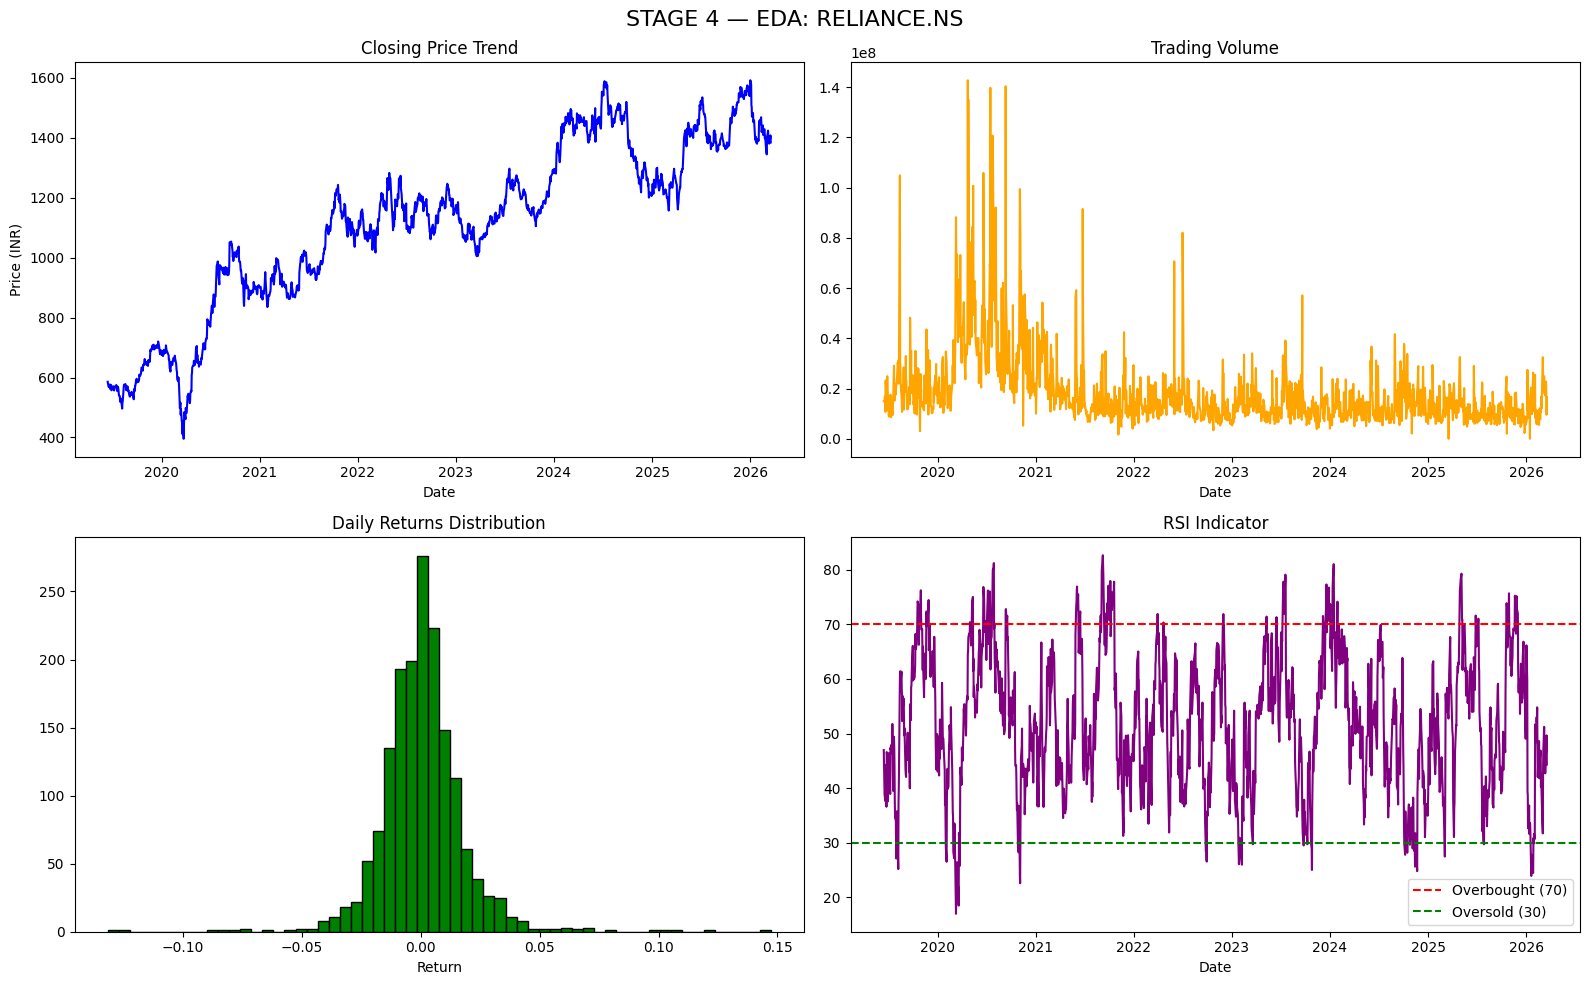

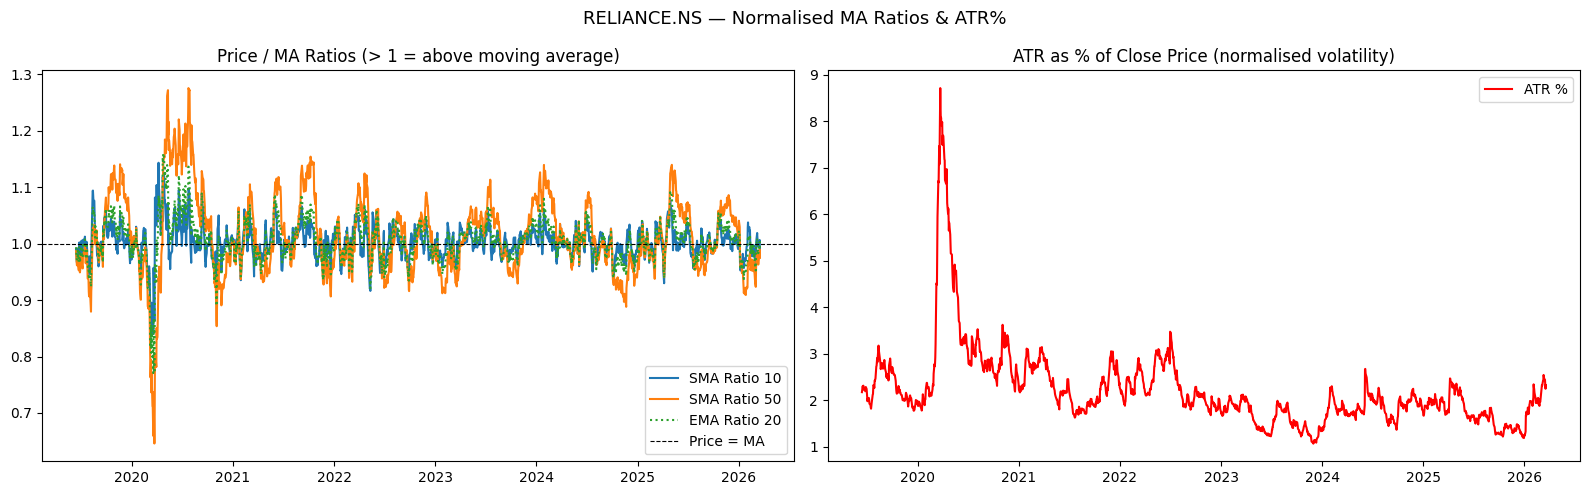

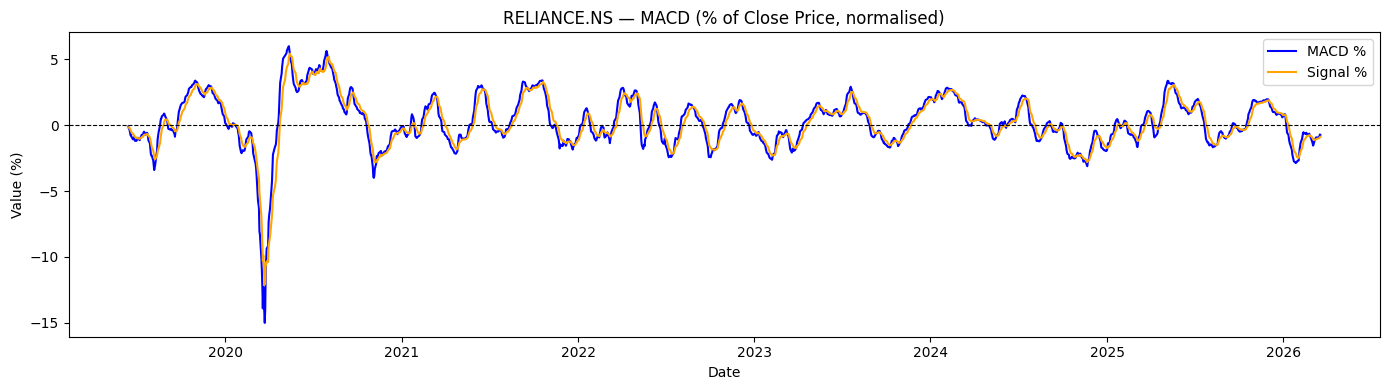

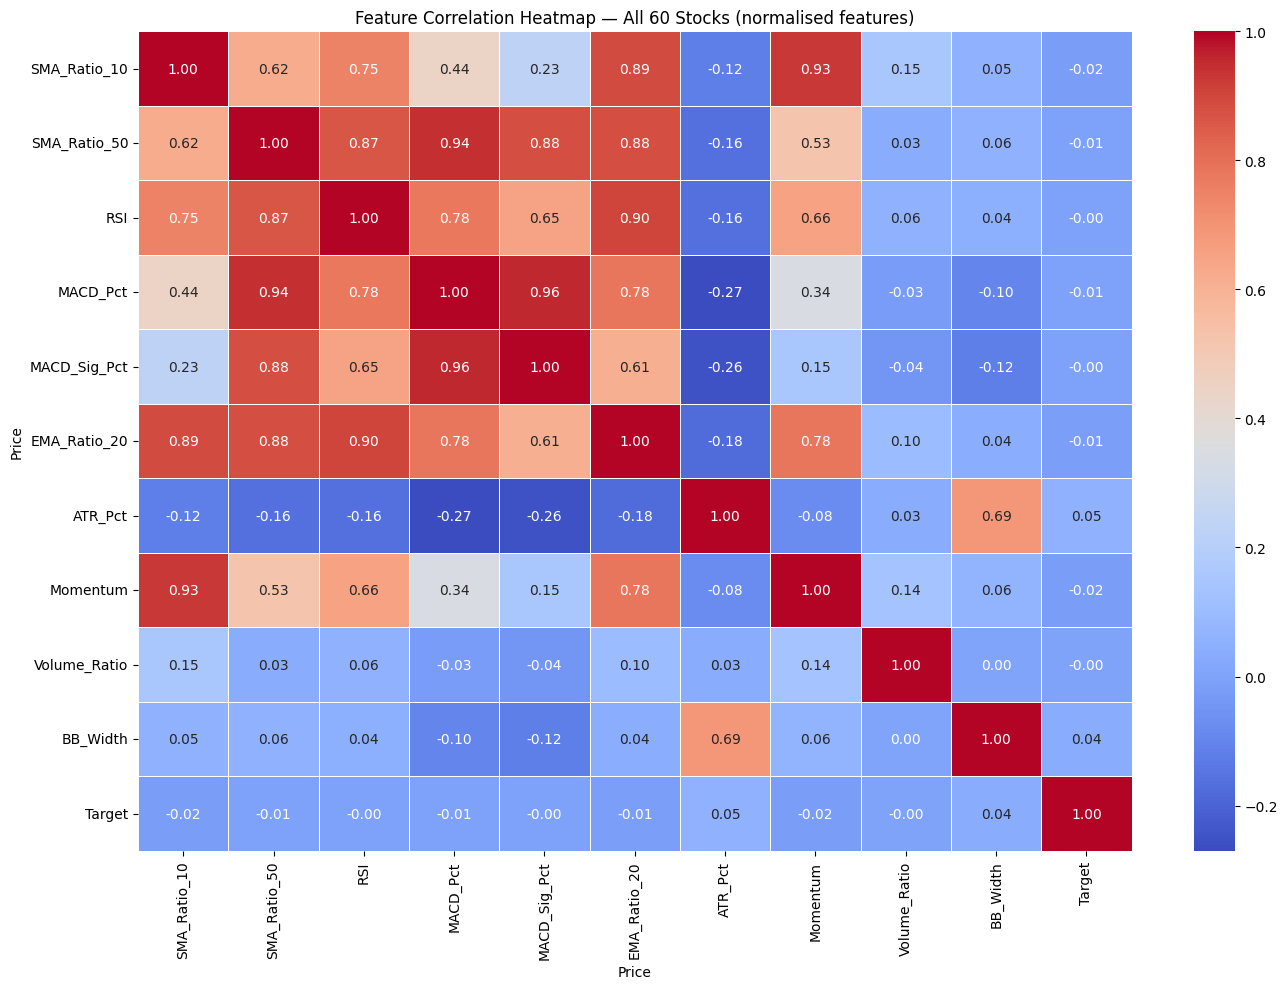

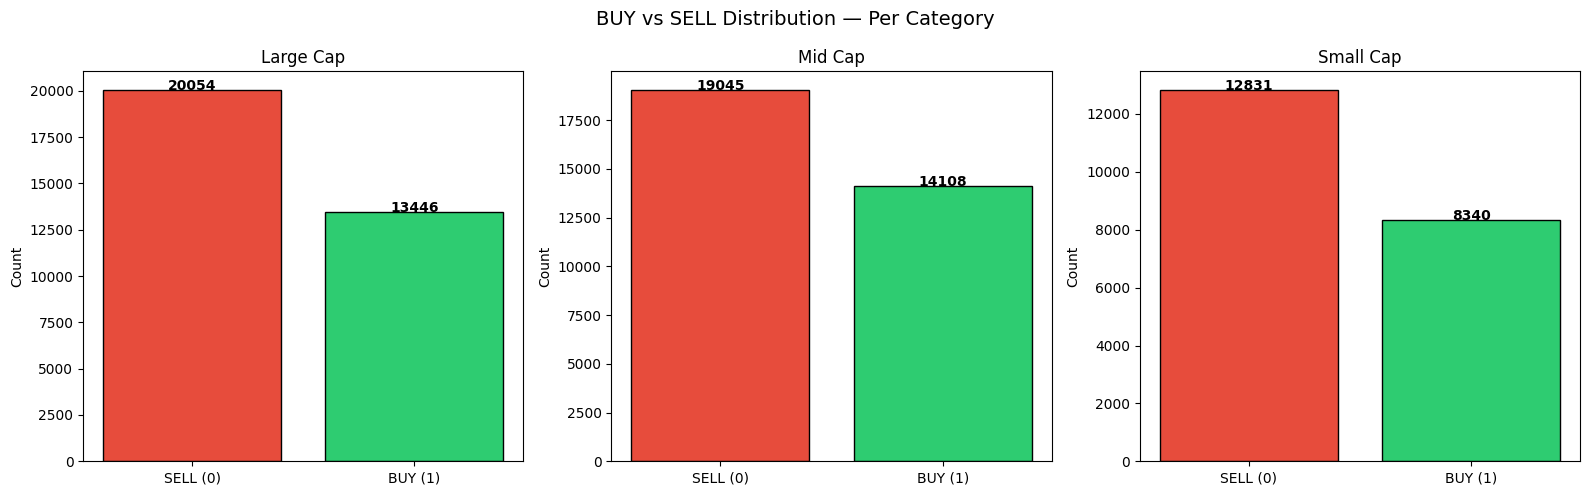

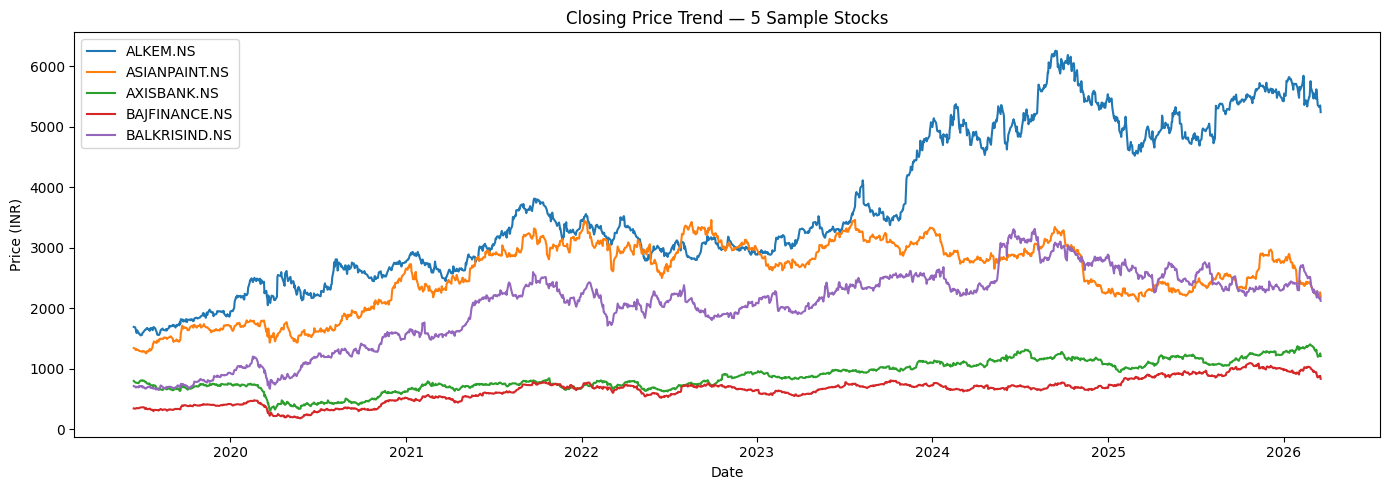


--- FEATURE CORRELATION WITH TARGET ---
  SMA_Ratio_10       : -0.0174
  SMA_Ratio_50       : -0.0056
  RSI                : -0.0031
  MACD_Pct           : -0.0072
  MACD_Sig_Pct       : -0.0033
  EMA_Ratio_20       : -0.0135
  ATR_Pct            : +0.0542
  Momentum           : -0.0175
  Volume_Ratio       : -0.0022
  BB_Width           : +0.0359


In [8]:
# ================================================================
# STAGE 4 — EDA
# ================================================================
print('\n' + '='*65)
print('STAGE 4 — EXPLORATORY DATA ANALYSIS (EDA)')
print('='*65)

os.makedirs('plots', exist_ok=True)

sample_df     = cleaned_dfs[0].copy()
sample_symbol = sample_df['Symbol'].iloc[0]
print(f'Sample Stock for EDA : {sample_symbol}')

print('\n--- DESCRIBE (sample stock) ---')
print(sample_df[FEATURES + ['Target']].describe().round(4))

print('\n--- TARGET DISTRIBUTION (Master) ---')
target_counts = master_df['Target'].value_counts()
buy_pct  = target_counts.get(1, 0) / len(master_df) * 100
sell_pct = target_counts.get(0, 0) / len(master_df) * 100
print(f'BUY  (1) : {target_counts.get(1, 0):>6}  ({buy_pct:.1f}%)')
print(f'SELL (0) : {target_counts.get(0, 0):>6}  ({sell_pct:.1f}%)')
if abs(buy_pct - sell_pct) > 15:
    print('Class imbalance detected — models will use class_weight=balanced')

# EDA Plots — saved as PNG
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f'STAGE 4 — EDA: {sample_symbol}', fontsize=16)
axes[0, 0].plot(sample_df.index, sample_df['Close'], color='blue')
axes[0, 0].set_title('Closing Price Trend')
axes[0, 0].set_xlabel('Date'); axes[0, 0].set_ylabel('Price (INR)')
axes[0, 1].plot(sample_df.index, sample_df['Volume'], color='orange')
axes[0, 1].set_title('Trading Volume'); axes[0, 1].set_xlabel('Date')
axes[1, 0].hist(sample_df['Daily_Return'].dropna(), bins=60,
                color='green', edgecolor='black')
axes[1, 0].set_title('Daily Returns Distribution'); axes[1, 0].set_xlabel('Return')
axes[1, 1].plot(sample_df.index, sample_df['RSI'], color='purple')
axes[1, 1].axhline(70, linestyle='--', color='red',   label='Overbought (70)')
axes[1, 1].axhline(30, linestyle='--', color='green', label='Oversold (30)')
axes[1, 1].set_title('RSI Indicator'); axes[1, 1].set_xlabel('Date')
axes[1, 1].legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f'{sample_symbol} — Normalised MA Ratios & ATR%', fontsize=13)
axes[0].plot(sample_df.index, sample_df['SMA_Ratio_10'], label='SMA Ratio 10')
axes[0].plot(sample_df.index, sample_df['SMA_Ratio_50'], label='SMA Ratio 50')
axes[0].plot(sample_df.index, sample_df['EMA_Ratio_20'], label='EMA Ratio 20', linestyle=':')
axes[0].axhline(1.0, linestyle='--', color='black', linewidth=0.8, label='Price = MA')
axes[0].set_title('Price / MA Ratios (> 1 = above moving average)')
axes[0].legend()
axes[1].plot(sample_df.index, sample_df['ATR_Pct'], color='red', label='ATR %')
axes[1].set_title('ATR as % of Close Price (normalised volatility)')
axes[1].legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(sample_df.index, sample_df['MACD_Pct'],     label='MACD %',   color='blue')
plt.plot(sample_df.index, sample_df['MACD_Sig_Pct'], label='Signal %', color='orange')
plt.axhline(0, linestyle='--', color='black', linewidth=0.8)
plt.title(f'{sample_symbol} — MACD (% of Close Price, normalised)')
plt.xlabel('Date'); plt.ylabel('Value (%)'); plt.legend()
plt.tight_layout()
plt.show()

numeric_cols = FEATURES + ['Target']
plt.figure(figsize=(14, 10))
sns.heatmap(master_df[numeric_cols].corr(), annot=True,
            fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap — All 60 Stocks (normalised features)')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('BUY vs SELL Distribution — Per Category', fontsize=14)
for i, cat in enumerate(CATEGORIES):
    cat_data = master_df[master_df['Category'] == cat]
    counts   = cat_data['Target'].value_counts().sort_index()
    axes[i].bar(['SELL (0)', 'BUY (1)'], counts.values,
                color=['#e74c3c', '#2ecc71'], edgecolor='black')
    axes[i].set_title(cat); axes[i].set_ylabel('Count')
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

sample_symbols = master_df['Symbol'].unique()[:5]
plt.figure(figsize=(14, 5))
for sym in sample_symbols:
    temp = master_df[master_df['Symbol'] == sym]
    plt.plot(temp['Date'], temp['Close'], label=sym)
plt.title('Closing Price Trend — 5 Sample Stocks')
plt.xlabel('Date'); plt.ylabel('Price (INR)'); plt.legend()
plt.tight_layout()
plt.show()

print('\n--- FEATURE CORRELATION WITH TARGET ---')
for feat in FEATURES:
    corr = master_df[feat].corr(master_df['Target'])
    print(f'  {feat:<18} : {corr:+.4f}')


In [9]:
# ================================================================
# STAGE 5 — MODEL DEVELOPMENT & TRAINING
# ================================================================
print('\n' + '='*65)
print('STAGE 5 — MODEL DEVELOPMENT & TRAINING')
print('='*65)

CAT_PARAMS = {
    'Large Cap': {
        'lr_C'            : 0.5,
        'lr_solver'       : 'saga',
        'rf_estimators'   : 200,
        'rf_depth'        : 8,
        'rf_min_split'    : 20,
        'rf_min_leaf'     : 10,
        'xgb_estimators'  : 200,
        'xgb_depth'       : 5,
        'lgbm_estimators' : 200,
        'lgbm_leaves'     : 31,
        'svm_C'           : 1.0,
    },
    'Mid Cap': {
        'lr_C'            : 0.3,
        'lr_solver'       : 'saga',
        'rf_estimators'   : 175,
        'rf_depth'        : 9,
        'rf_min_split'    : 15,
        'rf_min_leaf'     : 7,
        'xgb_estimators'  : 175,
        'xgb_depth'       : 6,
        'lgbm_estimators' : 175,
        'lgbm_leaves'     : 40,
        'svm_C'           : 0.5,
    },
    'Small Cap': {
        'lr_C'            : 0.2,
        'lr_solver'       : 'lbfgs',
        'rf_estimators'   : 150,
        'rf_depth'        : 10,
        'rf_min_split'    : 10,
        'rf_min_leaf'     : 5,
        'xgb_estimators'  : 150,
        'xgb_depth'       : 6,
        'lgbm_estimators' : 150,
        'lgbm_leaves'     : 50,
        'svm_C'           : 0.3,
    },
}

LEARNING_RATE = 0.05

print('\nSplit Strategy: Per-stock chronological 80/20 split per category')
print('Reason: Avoids data leakage — future data never seen during training\n')

category_data = {}

for cat in CATEGORIES:
    cat_df = master_df[master_df['Category'] == cat].copy()
    cat_df = cat_df.sort_values(['Symbol', 'Date']).reset_index(drop=True)

    n_stocks = cat_df['Symbol'].nunique()
    n_rows   = len(cat_df)

    if n_stocks < 15:
        print(f'WARNING [{cat}]: Only {n_stocks} stocks / {n_rows} rows.')

    train_list, test_list = [], []
    for symbol in cat_df['Symbol'].unique():
        stock_data = cat_df[cat_df['Symbol'] == symbol].copy()
        split      = int(len(stock_data) * 0.8)
        train_list.append(stock_data.iloc[:split])
        test_list.append(stock_data.iloc[split:])

    if not train_list:
        print(f'WARNING [{cat}]: No valid stocks remaining. Skipping category.')
        continue

    train_cat = pd.concat(train_list).reset_index(drop=True)
    test_cat  = pd.concat(test_list).reset_index(drop=True)

    X_train = train_cat[FEATURES]
    y_train = train_cat['Target']
    X_test  = test_cat[FEATURES]
    y_test  = test_cat['Target']

    sell_count       = (y_train == 0).sum()
    buy_count        = (y_train == 1).sum()
    scale_pos_weight = sell_count / buy_count if buy_count > 0 else 1.0

    scaler         = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    category_data[cat] = {
        'X_train'         : X_train,
        'y_train'         : y_train,
        'X_test'          : X_test,
        'y_test'          : y_test,
        'X_train_scaled'  : X_train_scaled,
        'X_test_scaled'   : X_test_scaled,
        'scale_pos_weight': scale_pos_weight,
        'scaler'          : scaler,
    }

    print(f'{cat:<12} | Stocks: {n_stocks} | '
          f'Train: {X_train.shape} | Test: {X_test.shape} | '
          f'scale_pos_weight: {scale_pos_weight:.3f}')

print('\nCategory-wise split complete')

os.makedirs('category_models', exist_ok=True)
print('Folder ready : category_models/')

all_results      = {}
ensemble_models  = {}
ensemble_preds   = {}
ensemble_probas  = {}

for cat in CATEGORIES:
    if cat not in category_data:
        continue
        
    print('\n' + '='*65)
    print(f'TRAINING CATEGORY : {cat}')
    print('='*65)

    X_train          = category_data[cat]['X_train']
    y_train          = category_data[cat]['y_train']
    X_test           = category_data[cat]['X_test']
    y_test           = category_data[cat]['y_test']
    X_train_scaled   = category_data[cat]['X_train_scaled']
    X_test_scaled    = category_data[cat]['X_test_scaled']
    scale_pos_weight = category_data[cat]['scale_pos_weight']
    scaler           = category_data[cat]['scaler']
    cat_key          = cat.replace(' ', '_').lower()
    cat_results      = {}
    p                = CAT_PARAMS[cat]

    # MODEL 1: LOGISTIC REGRESSION
    print(f'\n  Model 1 — Logistic Regression [{cat}]')
    lr_model = LogisticRegression(
        C            = p['lr_C'],
        penalty      = 'l2',
        solver       = p['lr_solver'],
        max_iter     = 1000,
        class_weight = 'balanced',
        random_state = 42
    )
    lr_model.fit(X_train_scaled, y_train)
    lr_pred = lr_model.predict(X_test_scaled)
    lr_acc  = accuracy_score(y_test, lr_pred)
    print(f'     Accuracy : {lr_acc:.4f}')
    print(classification_report(y_test, lr_pred, target_names=['SELL', 'BUY'], zero_division=0))
    joblib.dump({'model': lr_model, 'scaler': scaler}, f'category_models/LR_{cat_key}.pkl')
    print(f'     Saved : LR_{cat_key}.pkl')
    cat_results['Logistic Regression'] = lr_acc

    # MODEL 2: RANDOM FOREST
    print(f'\n  Model 2 — Random Forest [{cat}]')
    rf_model = RandomForestClassifier(
        n_estimators      = p['rf_estimators'],
        max_depth         = p['rf_depth'],
        min_samples_split = p['rf_min_split'],
        min_samples_leaf  = p['rf_min_leaf'],
        max_features      = 'sqrt',
        class_weight      = 'balanced',
        n_jobs            = -1,
        random_state      = 42
    )
    rf_model.fit(X_train, y_train)
    rf_pred = rf_model.predict(X_test)
    rf_acc  = accuracy_score(y_test, rf_pred)
    print(f'     Accuracy : {rf_acc:.4f}')
    print(classification_report(y_test, rf_pred, target_names=['SELL', 'BUY'], zero_division=0))
    joblib.dump(rf_model, f'category_models/RF_{cat_key}.pkl')
    print(f'     Saved : RF_{cat_key}.pkl')
    cat_results['Random Forest'] = rf_acc

    # MODEL 3: XGBOOST
    print(f'\n  Model 3 — XGBoost [{cat}]')
    xgb_model = XGBClassifier(
        n_estimators     = p['xgb_estimators'],
        learning_rate    = LEARNING_RATE,
        max_depth        = p['xgb_depth'],
        subsample        = 0.8,
        colsample_bytree = 0.8,
        scale_pos_weight = scale_pos_weight,
        gamma            = 0.2,
        min_child_weight = 5,
        reg_alpha        = 0.1,
        reg_lambda       = 1.5,
        tree_method      = 'hist',
        n_jobs           = -1,
        random_state     = 42,
        verbosity        = 0,
    )
    xgb_model.fit(X_train, y_train)
    xgb_pred = xgb_model.predict(X_test)
    xgb_acc  = accuracy_score(y_test, xgb_pred)
    print(f'     Accuracy : {xgb_acc:.4f}')
    print(classification_report(y_test, xgb_pred, target_names=['SELL', 'BUY'], zero_division=0))
    joblib.dump(xgb_model, f'category_models/XGB_{cat_key}.pkl')
    print(f'     Saved : XGB_{cat_key}.pkl')
    cat_results['XGBoost'] = xgb_acc

    # MODEL 4: LIGHTGBM
    print(f'\n  Model 4 — LightGBM [{cat}]')
    lgbm_model = LGBMClassifier(
        n_estimators      = p['lgbm_estimators'],
        learning_rate     = LEARNING_RATE,
        max_depth         = p['xgb_depth'],
        num_leaves        = p['lgbm_leaves'],
        subsample         = 0.8,
        colsample_bytree  = 0.8,
        min_child_samples = 20,
        reg_alpha         = 0.1,
        reg_lambda        = 1.5,
        scale_pos_weight  = scale_pos_weight,
        n_jobs            = -1,
        random_state      = 42,
        force_col_wise    = True,
        verbose           = -1,
    )
    lgbm_model.fit(X_train, y_train)
    lgbm_pred = lgbm_model.predict(X_test)
    lgbm_acc  = accuracy_score(y_test, lgbm_pred)
    print(f'     Accuracy : {lgbm_acc:.4f}')
    print(classification_report(y_test, lgbm_pred, target_names=['SELL', 'BUY'], zero_division=0))
    joblib.dump(lgbm_model, f'category_models/LGBM_{cat_key}.pkl')
    print(f'     Saved : LGBM_{cat_key}.pkl')
    cat_results['LightGBM'] = lgbm_acc

    # MODEL 5: SVM
    print(f'\n  Model 5 — SVM [{cat}]')
    svm_sample_size = min(MAX_SVM_ROWS, max(200, int(len(X_train_scaled) * 0.3)))
    
    # FIX: Random stratified sampling instead of sequential tail (which caused single class errors)
    y_train_arr = y_train.values
    from sklearn.utils import resample
    try:
        X_train_svm, y_train_svm = resample(X_train_scaled, y_train_arr, 
                                            n_samples=svm_sample_size, 
                                            stratify=y_train_arr,
                                            random_state=42)
    except ValueError:
        # Fallback if stratify fails due to extreme class imbalance
        X_train_svm, y_train_svm = resample(X_train_scaled, y_train_arr, 
                                            n_samples=svm_sample_size,
                                            random_state=42)
        
    print(f'     SVM trains on {svm_sample_size} rows (random stratify, hard-capped at {MAX_SVM_ROWS})')
    svm_model = SVC(
        C            = p['svm_C'],
        kernel       = 'rbf',
        gamma        = 'scale',
        class_weight = 'balanced',
        probability  = True,
        random_state = 42
    )
    svm_model.fit(X_train_svm, y_train_svm)
    svm_pred = svm_model.predict(X_test_scaled)
    svm_acc  = accuracy_score(y_test, svm_pred)
    print(f'     Accuracy : {svm_acc:.4f}')
    print(classification_report(y_test, svm_pred, target_names=['SELL', 'BUY'], zero_division=0))
    joblib.dump({'model': svm_model, 'scaler': scaler}, f'category_models/SVM_{cat_key}.pkl')
    print(f'     Saved : SVM_{cat_key}.pkl')
    cat_results['SVM'] = svm_acc

    # MODEL 6: ENSEMBLE
    print(f'\n  Model 6 — Ensemble Voting [{cat}]')
    ensemble_model = PreFittedVotingClassifier(
        estimators=[
            ('xgb',  xgb_model),
            ('rf',   rf_model),
            ('lgbm', lgbm_model),
        ]
    )
    ensemble_model.fit(X_train, y_train)
    ensemble_pred  = ensemble_model.predict(X_test)
    ensemble_acc   = accuracy_score(y_test, ensemble_pred)
    print(f'     Accuracy : {ensemble_acc:.4f}')
    print(classification_report(y_test, ensemble_pred, target_names=['SELL', 'BUY'], zero_division=0))
    joblib.dump(ensemble_model, f'category_models/ENSEMBLE_{cat_key}.pkl')
    print(f'     Saved : ENSEMBLE_{cat_key}.pkl')
    cat_results['Ensemble'] = ensemble_acc
    ensemble_models[cat]    = ensemble_model
    ensemble_preds[cat]     = ensemble_pred

    if 1 in ensemble_model.classes_:
        class_1_idx          = list(ensemble_model.classes_).index(1)
        ensemble_probas[cat] = ensemble_model.predict_proba(X_test)[:, class_1_idx]
    else:
        # If the training sample unexpectedly had 0 "BUY" cases, array defaults to 0% BUY probability
        ensemble_probas[cat] = np.zeros(len(X_test))

    joblib.dump(scaler, f'category_models/SCALER_{cat_key}.pkl')
    print(f'     Saved : SCALER_{cat_key}.pkl')

    all_results[cat] = cat_results
    print(f'\n  All 6 models saved for [{cat}]')



STAGE 5 — MODEL DEVELOPMENT & TRAINING

Split Strategy: Per-stock chronological 80/20 split per category
Reason: Avoids data leakage — future data never seen during training

Large Cap    | Stocks: 20 | Train: (26800, 10) | Test: (6700, 10) | scale_pos_weight: 1.419
Mid Cap      | Stocks: 20 | Train: (26521, 10) | Test: (6632, 10) | scale_pos_weight: 1.260
Small Cap    | Stocks: 20 | Train: (16927, 10) | Test: (4244, 10) | scale_pos_weight: 1.448

Category-wise split complete
Folder ready : category_models/

TRAINING CATEGORY : Large Cap

  Model 1 — Logistic Regression [Large Cap]
     Accuracy : 0.5834
              precision    recall  f1-score   support

        SELL       0.65      0.78      0.71      4335
         BUY       0.35      0.22      0.27      2365

    accuracy                           0.58      6700
   macro avg       0.50      0.50      0.49      6700
weighted avg       0.54      0.58      0.55      6700

     Saved : LR_large_cap.pkl

  Model 2 — Random Forest [La


STAGE 6 — MODEL EVALUATION & TUNING

ACCURACY PIVOT TABLE — ALL MODELS x ALL CATEGORIES
Category             Large Cap  Mid Cap  Small Cap
Model                                             
Ensemble                0.5391   0.5314     0.5408
LightGBM                0.5358   0.5317     0.5337
Logistic Regression     0.5834   0.5784     0.5945
Random Forest           0.5555   0.5472     0.5450
SVM                     0.5851   0.5418     0.4218
XGBoost                 0.5276   0.5243     0.5408

EXTENDED METRICS — ENSEMBLE MODEL PER CATEGORY
Category      Accuracy  Precision   Recall       F1   ROC-AUC
------------------------------------------------------------
[WARN] Large Cap     0.5391     0.3557   0.3767   0.3659    0.5008
[WARN] Mid Cap       0.5314     0.3679   0.4321   0.3974    0.5165
[WARN] Small Cap     0.5408     0.3397   0.3895   0.3629    0.5077

CONFUSION MATRICES — ENSEMBLE MODEL


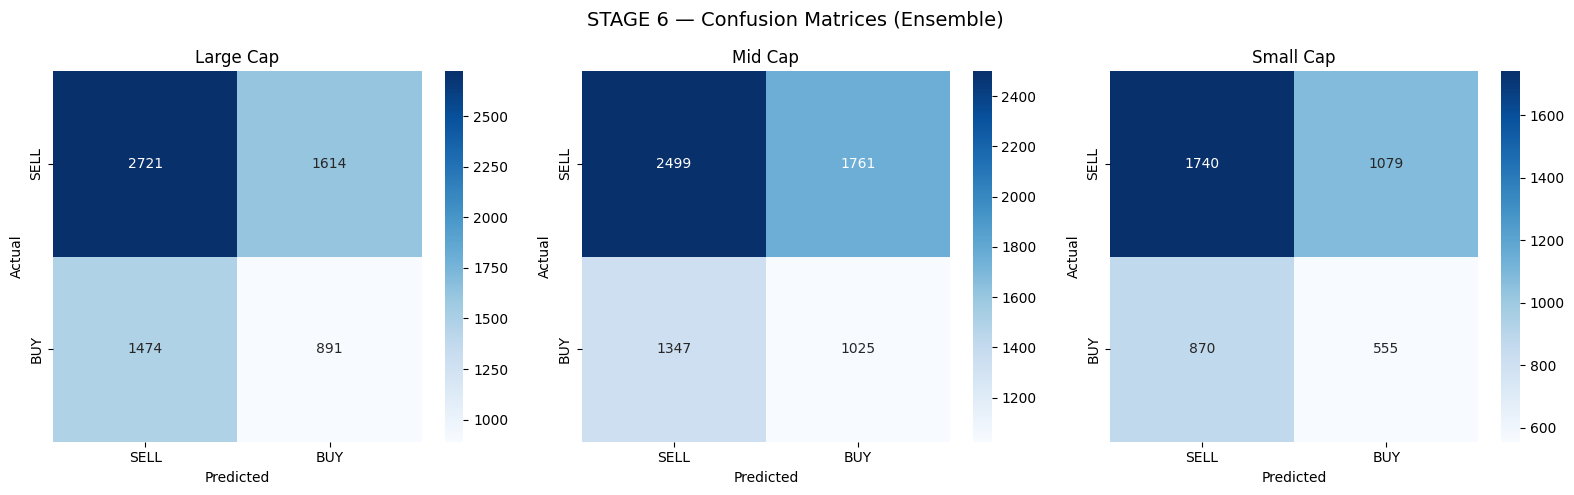


3-FOLD CROSS-VALIDATION — RANDOM FOREST (fast proxy for ensemble) PER CATEGORY
Category       CV Mean    CV Std      Min      Max
--------------------------------------------------
  Large Cap       0.5675    0.0088   0.5591   0.5796
  Mid Cap         0.5565    0.0039   0.5512   0.5604
  Small Cap       0.5796    0.0076   0.5739   0.5904


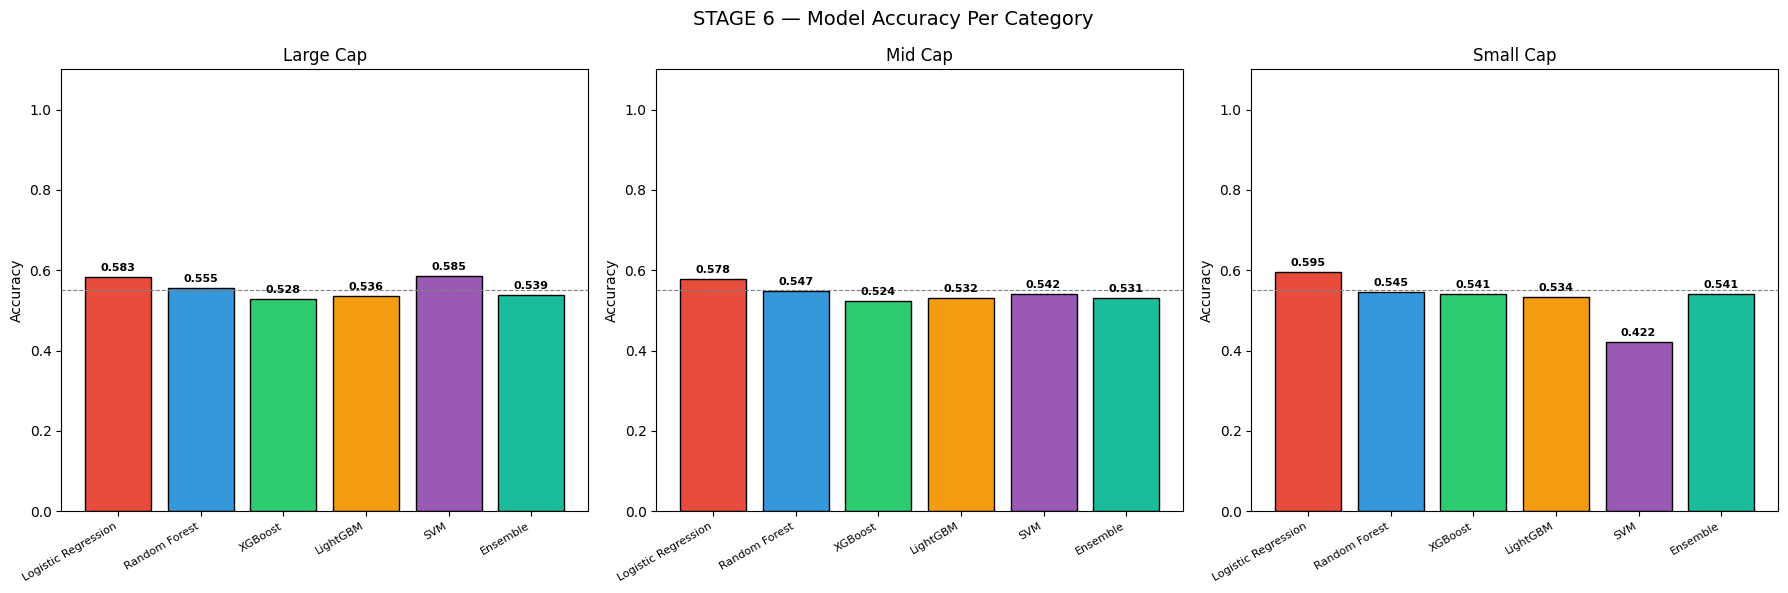

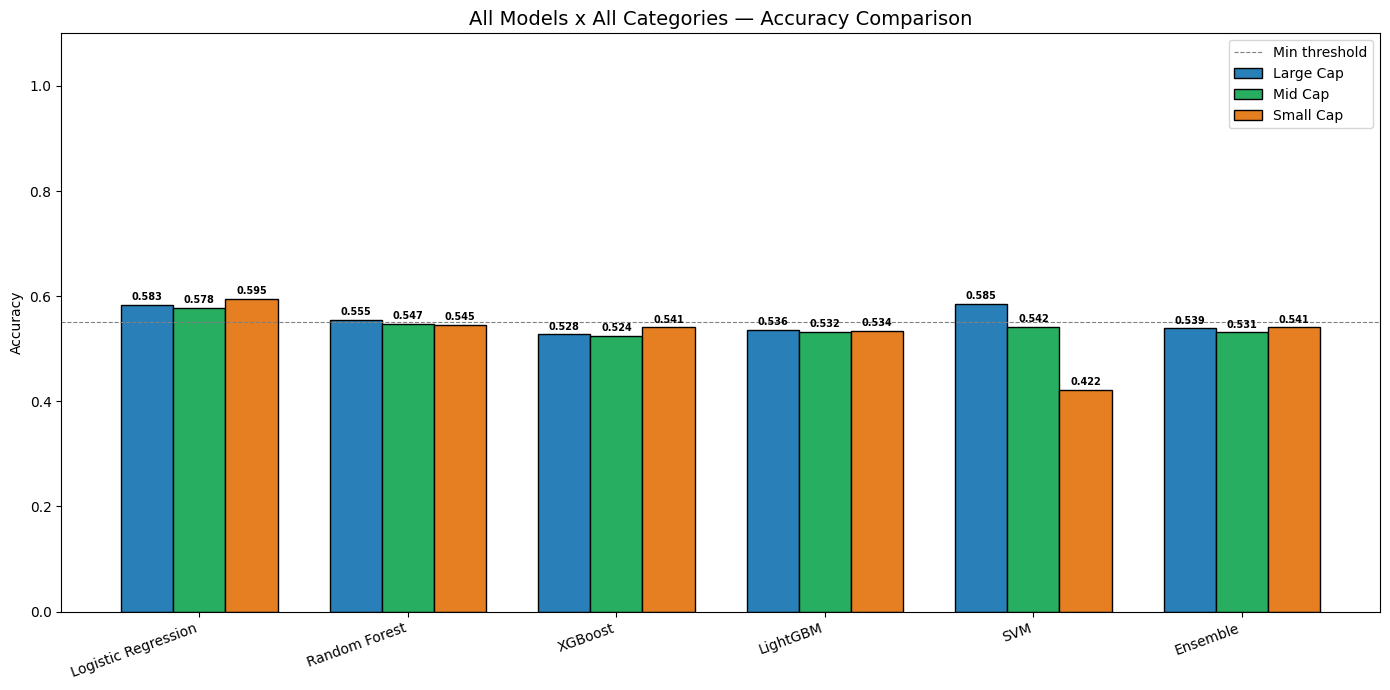


--- BEST MODEL PER CATEGORY ---
  Large Cap    -> SVM                    Accuracy = 0.5851
  Mid Cap      -> Logistic Regression    Accuracy = 0.5784
  Small Cap    -> Logistic Regression    Accuracy = 0.5945

--- OVERALL BEST MODEL ---
  Logistic Regression on Small Cap -> Accuracy = 0.5945


In [10]:
# ================================================================
# STAGE 6 — MODEL EVALUATION & TUNING
# ================================================================
print('\n' + '='*65)
print('STAGE 6 — MODEL EVALUATION & TUNING')
print('='*65)

rows = []
for cat, model_results in all_results.items():
    for model_name, acc in model_results.items():
        rows.append({'Category': cat, 'Model': model_name, 'Accuracy': round(acc, 4)})

results_df  = pd.DataFrame(rows)
pivot_table = results_df.pivot(index='Model', columns='Category', values='Accuracy')
print('\nACCURACY PIVOT TABLE — ALL MODELS x ALL CATEGORIES')
print(pivot_table.to_string())

print('\nEXTENDED METRICS — ENSEMBLE MODEL PER CATEGORY')
print(f'{"Category":<12} {"Accuracy":>9} {"Precision":>10} '
      f'{"Recall":>8} {"F1":>8} {"ROC-AUC":>9}')
print('-'*60)

for cat in CATEGORIES:
    if cat not in ensemble_preds:
        continue
        
    y_test  = category_data[cat]['y_test']
    y_pred  = ensemble_preds[cat]
    y_proba = ensemble_probas[cat]

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)

    try:
        auc = roc_auc_score(y_test, y_proba)
    except ValueError:
        auc = float('nan')
        print(f'  ROC-AUC skipped for {cat} — only one class in y_test')

    status = 'OK' if acc >= 0.55 else 'WARN'
    print(f'[{status}] {cat:<10} {acc:>9.4f} {prec:>10.4f} '
          f'{rec:>8.4f} {f1:>8.4f} {auc:>9.4f}')

# Confusion Matrices
print('\nCONFUSION MATRICES — ENSEMBLE MODEL')
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('STAGE 6 — Confusion Matrices (Ensemble)', fontsize=14)
for i, cat in enumerate(CATEGORIES):
    if cat not in ensemble_preds:
        continue
    y_test = category_data[cat]['y_test']
    y_pred = ensemble_preds[cat]
    cm     = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['SELL', 'BUY'], yticklabels=['SELL', 'BUY'])
    axes[i].set_title(f'{cat}')
    axes[i].set_xlabel('Predicted'); axes[i].set_ylabel('Actual')
plt.tight_layout()
plt.show()

# Cross-Validation
print('\n3-FOLD CROSS-VALIDATION — RANDOM FOREST (fast proxy for ensemble) PER CATEGORY')
print(f'{"Category":<12} {"CV Mean":>9} {"CV Std":>9} {"Min":>8} {"Max":>8}')
print('-'*50)

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for cat in CATEGORIES:
    if cat not in category_data:
        continue
    X_cv = category_data[cat]['X_train']
    y_cv = category_data[cat]['y_train']
    cv_rf = RandomForestClassifier(
        n_estimators      = CAT_PARAMS[cat]['rf_estimators'],
        max_depth         = CAT_PARAMS[cat]['rf_depth'],
        min_samples_split = CAT_PARAMS[cat]['rf_min_split'],
        min_samples_leaf  = CAT_PARAMS[cat]['rf_min_leaf'],
        max_features      = 'sqrt',
        class_weight      = 'balanced',
        n_jobs            = -1,
        random_state      = 42
    )
    cv_scores = cross_val_score(cv_rf, X_cv, y_cv, cv=skf, scoring='accuracy')
    print(f'  {cat:<12} {cv_scores.mean():>9.4f} {cv_scores.std():>9.4f} '
          f'{cv_scores.min():>8.4f} {cv_scores.max():>8.4f}')

# Accuracy Bar Charts
model_names = ['Logistic Regression', 'Random Forest', 'XGBoost',
               'LightGBM', 'SVM', 'Ensemble']
bar_colors  = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('STAGE 6 — Model Accuracy Per Category', fontsize=14)
for i, cat in enumerate(CATEGORIES):
    cat_subset = results_df[results_df['Category'] == cat].set_index('Model')
    accs = [cat_subset.loc[m, 'Accuracy'] if m in cat_subset.index else 0
            for m in model_names]
    bars = axes[i].bar(model_names, accs, color=bar_colors, edgecolor='black')
    axes[i].set_title(cat, fontsize=12)
    axes[i].set_ylabel('Accuracy'); axes[i].set_ylim(0, 1.1)
    axes[i].axhline(0.55, linestyle='--', color='gray', linewidth=0.8, label='Min threshold (0.55)')
    axes[i].set_xticks(range(len(model_names)))
    axes[i].set_xticklabels(model_names, rotation=30, ha='right', fontsize=8)
    for bar, acc in zip(bars, accs):
        axes[i].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.01,
                     f'{acc:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 7))
x          = np.arange(len(model_names))
width      = 0.25
cat_colors = ['#2980b9', '#27ae60', '#e67e22']
for i, cat in enumerate(CATEGORIES):
    cat_subset = results_df[results_df['Category'] == cat].set_index('Model')
    accs = [cat_subset.loc[m, 'Accuracy'] if m in cat_subset.index else 0
            for m in model_names]
    bars = ax.bar(x + i * width, accs, width, label=cat,
                  color=cat_colors[i], edgecolor='black')
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{acc:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')
ax.set_title('All Models x All Categories — Accuracy Comparison', fontsize=14)
ax.set_xticks(x + width)
ax.set_xticklabels(model_names, rotation=20, ha='right')
ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1.1)
ax.axhline(0.55, linestyle='--', color='gray', linewidth=0.8, label='Min threshold')
ax.legend()
plt.tight_layout()
plt.show()

print('\n--- BEST MODEL PER CATEGORY ---')
for cat in CATEGORIES:
    if not results_df.empty and cat in results_df['Category'].values:
        cat_subset = results_df[results_df['Category'] == cat]
        best_row   = cat_subset.loc[cat_subset['Accuracy'].idxmax()]
        print(f'  {cat:<12} -> {best_row["Model"]:<22} Accuracy = {best_row["Accuracy"]:.4f}')
    else:
        print(f'  {cat:<12} -> NO DATA OR MODELS AVAILABLE')

print('\n--- OVERALL BEST MODEL ---')
if not results_df.empty:
    best_overall = results_df.loc[results_df['Accuracy'].idxmax()]
    print(f'  {best_overall["Model"]} on {best_overall["Category"]}'
          f' -> Accuracy = {best_overall["Accuracy"]:.4f}')
else:
    print('  NO MODELS TRAINED')


In [11]:
# ================================================================
# SAVED FILES SUMMARY
# ================================================================
print('\n' + '='*65)
print('SAVED FILES IN category_models/')
print('='*65)
saved_files = sorted(os.listdir('category_models'))
for f in saved_files:
    size_kb = os.path.getsize(f'category_models/{f}') / 1024
    print(f'  {f:<45} {size_kb:>8.1f} KB')
print(f'\n  Total files saved : {len(saved_files)}')



SAVED FILES IN category_models/
  ENSEMBLE_large_cap.pkl                          4278.5 KB
  ENSEMBLE_mid_cap.pkl                            5678.9 KB
  ENSEMBLE_small_cap.pkl                          6541.8 KB
  LGBM_large_cap.pkl                               529.4 KB
  LGBM_mid_cap.pkl                                 651.3 KB
  LGBM_small_cap.pkl                               510.5 KB
  LR_large_cap.pkl                                   1.9 KB
  LR_mid_cap.pkl                                     1.9 KB
  LR_small_cap.pkl                                   1.9 KB
  RF_large_cap.pkl                                3292.7 KB
  RF_mid_cap.pkl                                  4463.0 KB
  RF_small_cap.pkl                                5573.6 KB
  SCALER_large_cap.pkl                               1.2 KB
  SCALER_mid_cap.pkl                                 1.2 KB
  SCALER_small_cap.pkl                               1.2 KB
  SVM_large_cap.pkl                                 47.3 KB
  SVM_m

In [ ]:
# ================================================================
# LIVE REAL-TIME PREDICTION
# ================================================================
def predict_live(symbol, category):
    model_key = category.lower().replace(' ', '_')
    model     = joblib.load(f'category_models/ENSEMBLE_{model_key}.pkl')

    df_live = yf.download(symbol, period='200d', progress=False)

    if df_live.empty:
        print(f'{symbol:<22} — no data returned')
        return

    if isinstance(df_live.columns, pd.MultiIndex):
        df_live.columns = df_live.columns.get_level_values(0)

    required = ['Open', 'High', 'Low', 'Close', 'Volume']
    if not all(col in df_live.columns for col in required):
        print(f'{symbol:<22} — missing required columns')
        return

    close = df_live['Close'].squeeze()
    high  = df_live['High'].squeeze()
    low   = df_live['Low'].squeeze()
    vol   = df_live['Volume'].squeeze()

    sma_10 = ta.trend.sma_indicator(close=close, window=10)
    sma_50 = ta.trend.sma_indicator(close=close, window=50)
    ema_20 = ta.trend.ema_indicator(close=close, window=20)
    atr    = ta.volatility.average_true_range(high=high, low=low, close=close)
    vol_ma = vol.rolling(window=20).mean()
    macd_obj  = ta.trend.MACD(close=close)
    macd_raw  = macd_obj.macd()
    macd_sig  = macd_obj.macd_signal()
    bb_obj    = ta.volatility.BollingerBands(close=close, window=20)

    df_live['SMA_Ratio_10']  = close / sma_10
    df_live['SMA_Ratio_50']  = close / sma_50
    df_live['EMA_Ratio_20']  = close / ema_20
    df_live['ATR_Pct']       = atr / close * 100
    df_live['Volume_Ratio']  = vol / vol_ma
    df_live['MACD_Pct']      = macd_raw / close * 100
    df_live['MACD_Sig_Pct']  = macd_sig / close * 100
    df_live['RSI']           = ta.momentum.rsi(close=close, window=14)
    df_live['Momentum']      = close.pct_change(5)
    df_live['BB_Width']      = bb_obj.bollinger_wband()

    df_live.dropna(inplace=True)

    if df_live.empty:
        print(f'{symbol:<22} — insufficient data after indicator computation')
        return

    latest_row = df_live[FEATURES].iloc[[-1]]
    pred       = model.predict(latest_row)
    proba      = model.predict_proba(latest_row)[0]
    signal     = 'BUY' if pred[0] == 1 else 'SELL'
    confidence = max(proba) * 100
    last_price = float(df_live['Close'].squeeze().iloc[-1])
    last_date  = df_live.index[-1].strftime('%Y-%m-%d')

    print(f'{symbol:<22} | {signal:<4} | Confidence: {confidence:>5.1f}%'
          f' | Rs {last_price:>9.2f} | As of: {last_date}')


print('\n' + '='*65)
print('LIVE REAL-TIME PREDICTIONS — TODAY\'S BUY/SELL SIGNALS')
print(f'   Generated : {datetime.today().strftime("%Y-%m-%d %H:%M")}')
print(f'   Note      : Based on last available market close (EOD data)')
print('='*65)

for cap_label in CATEGORIES:
    print(f'\n{cap_label}:')
    for sym, cat in STOCKS.items():
        if cat == cap_label:
            try:
                predict_live(sym, cat)
            except Exception as e:
                print(f'ERROR {sym:<22} — {e}')


print('''
HOW TO LOAD AND PREDICT — GUIDE
=================================
FEATURES = [
    'SMA_Ratio_10', 'SMA_Ratio_50', 'RSI', 'MACD_Pct', 'MACD_Sig_Pct',
    'EMA_Ratio_20', 'ATR_Pct', 'Momentum', 'Volume_Ratio', 'BB_Width'
]

--- Tree models (XGB / RF / LGBM / ENSEMBLE) — no scaling needed ---
  import joblib, pandas as pd
  model   = joblib.load('category_models/XGB_large_cap.pkl')
  new_row = pd.DataFrame([{...}])
  pred    = model.predict(new_row[FEATURES])
  print('BUY' if pred[0] == 1 else 'SELL')

--- LR / SVM — scaler bundled inside pkl ---
  bundle   = joblib.load('category_models/LR_large_cap.pkl')
  model    = bundle['model']
  scaler   = bundle['scaler']
  X_scaled = scaler.transform(new_row[FEATURES])
  pred     = model.predict(X_scaled)
  print('BUY' if pred[0] == 1 else 'SELL')
''')

print('='*65)
print('STOCK ML — FULL LIFECYCLE COMPLETE (FIXED v3)')
print(f'   Bugs fixed : 25 (v2) + 26 (v3) = 51 total')
print('='*65)



LIVE REAL-TIME PREDICTIONS — TODAY'S BUY/SELL SIGNALS
   Generated : 2026-03-28 08:58
   Note      : Based on last available market close (EOD data)

Large Cap:
RELIANCE.NS            | BUY  | Confidence:  53.4% | Rs   1348.10 | As of: 2026-03-27
HDFCBANK.NS            | BUY  | Confidence:  60.2% | Rs    756.20 | As of: 2026-03-27
INFY.NS                | BUY  | Confidence:  53.0% | Rs   1269.70 | As of: 2026-03-27
TCS.NS                 | BUY  | Confidence:  57.7% | Rs   2389.80 | As of: 2026-03-27
ICICIBANK.NS           | BUY  | Confidence:  51.1% | Rs   1233.80 | As of: 2026-03-27
KOTAKBANK.NS           | SELL | Confidence:  58.0% | Rs    366.15 | As of: 2026-03-27
LT.NS                  | BUY  | Confidence:  69.5% | Rs   3564.10 | As of: 2026-03-27
AXISBANK.NS            | SELL | Confidence:  58.2% | Rs   1205.20 | As of: 2026-03-27
HINDUNILVR.NS          | SELL | Confidence:  50.7% | Rs   2074.40 | As of: 2026-03-27
ITC.NS                 | SELL | Confidence:  50.1% | Rs    294.7